In [14]:
# NFkB–IkBα–IkBε model for M178 final project
# Daniel Chang 

In [15]:
# packages I am using for this 

import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [92]:
# Parameters

params = {
    "k_a" : 0.1, # association NFkB + IkB <-> complex
    "k_d" : 0.0006, # dissociation NfKb:IkB <-> NFkB + IkB
    "r" : 0.2,   # IKK-meditated degradation (free IkB and complexes )
    "g" : 0.012,  # constitutive degradation of IkB

    "f_a" : 10, # NFkB binding to promoter 
    "f_d" : 200, # NFkB unbinding to promoter

    # transcription and translation controls
    "a1" : 0.0074,  # synthesis of IkBa from free promoter P1
    "b1" : 20,  # synthesis of IkBa from bound promoter B1
    "a2" : 0.0002,  # synthesis of IkBa from free promoter P2
    "b2" : 8  # synthesis of IkBa from bound promoter B2
 }

In [97]:
# ODE System

def IKK_pulse(t, on=0, off=40):
    if t >= on and t <= off:
        return 1
    else:
        return 0

def nfkb_system(y, t, p):
    N, I_a, I_e, C1, C2, P1, P2, B1, B2 = y
    k_a = p["k_a"]
    k_d = p["k_d"]
    r   = p["r"]
    g   = p["g"]
    f_a = p["f_a"]
    f_d = p["f_d"]
    a1  = p["a1"]
    b1  = p["b1"]
    a2  = p["a2"]
    b2  = p["b2"]

    r_eff = r * IKK_pulse(t)

    # dN/dt  (free NFkB)
    dNdt = (
        -k_a * N * I_a + k_d * C1 + r_eff * C1
        -k_a * N * I_e + k_d * C2 + r_eff * C2
        -f_a * N * P1 + f_d * B1
        -f_a * N * P2 + f_d * B2
    )

    # dI_a/dt  (IkBα)
    dIadt = (
        -k_a * N * I_a + k_d * C1
        - r_eff * I_a - g * I_a
        + a1 * P1 + b1 * B1
    )

    # dI_e/dt  (IkBε)
    dIedt = (
        -k_a * N * I_e + k_d * C2
        - r_eff * I_e - g * I_e
        + a2 * P2 + b2 * B2
    )

    # dC1/dt  (NFkB:IkBα)
    dC1dt = k_a * N * I_a - k_d * C1 - r_eff * C1

    # dC2/dt  (NFkB:IkBε)
    dC2dt = k_a * N * I_e - k_d * C2 - r_eff * C2

    # dP1/dt  (IkBα promoter)
    dP1dt = -f_a * N * P1 + f_d * B1

    # dP2/dt  (IkBε promoter)
    dP2dt = -f_a * N * P2 + f_d * B2

    # dB1/dt  (NFkB:prIkBα)
    dB1dt = f_a * N * P1 - f_d * B1

    # dB2/dt  (NFkB:prIkBε)
    dB2dt = f_a * N * P2 - f_d * B2

    return [dNdt, dIadt, dIedt, dC1dt, dC2dt, dP1dt, dP2dt, dB1dt, dB2dt]

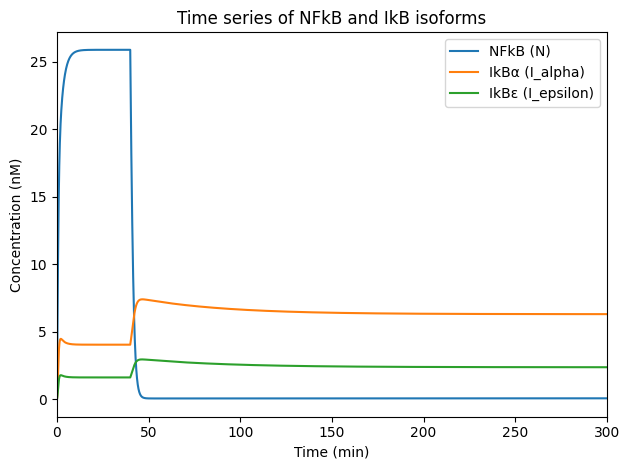

In [98]:
# running simulation for time series

def run_simulation(params, T_end=500, num_points=5001):
    t = np.linspace(0, T_end, num_points)

    # Initial conditions: NFkB mostly sequestered in complexes
    N0   = 0.0      # free NFkB low at rest
    I_a0 = 0.0      # free IkBα
    I_e0 = 0.0      # free IkBε
    C10  = 100.0    # NFkB:IkBα complex 
    C20  = 0.0      # NFkB:IkBε complex 
    P10  = 1.0      # free promoters
    P20  = 1.0
    B10  = 0.0
    B20  = 0.0

    y0 = [N0, I_a0, I_e0, C10, C20, P10, P20, B10, B20]

    sol = odeint(nfkb_system, y0, t, args=(params,))
    return t, sol


# Time series run
t, sol = run_simulation(params)
N   = sol[:, 0]
I_a = sol[:, 1]
I_e = sol[:, 2]
plt.figure()
plt.plot(t, sol[:,0], label="NFkB (N)")
plt.plot(t, sol[:,1], label="IkBα (I_alpha)")
plt.plot(t, sol[:,2], label="IkBε (I_epsilon)")
plt.xlabel("Time (min)")
plt.ylabel("Concentration (nM)")
plt.xlim(0, 300)
plt.legend()
plt.title("Time series of NFkB and IkB isoforms")
plt.tight_layout()
plt.show()


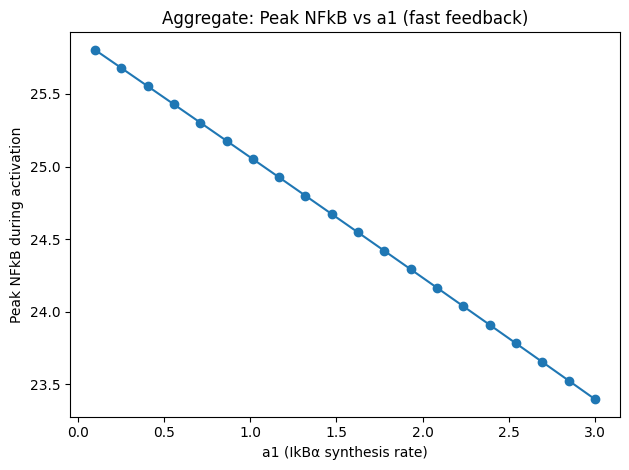

In [84]:
# peak NFkB vs a1 
# a1 fast feedback strength

a1_values = np.linspace(0.1, 3.0, 20)   
peak_N = []

for a1 in a1_values:
    p = params.copy()
    p["a1"] = a1
    t, sol = run_simulation(p)
    N = sol[:, 0]
    peak_N.append(np.max(N))

plt.figure()
plt.plot(a1_values, peak_N, marker="o")
plt.xlabel("a1 (IkBα synthesis rate)")
plt.ylabel("Peak NFkB during activation")
plt.title("Aggregate: Peak NFkB vs a1 (fast feedback)")
plt.tight_layout()
plt.show()


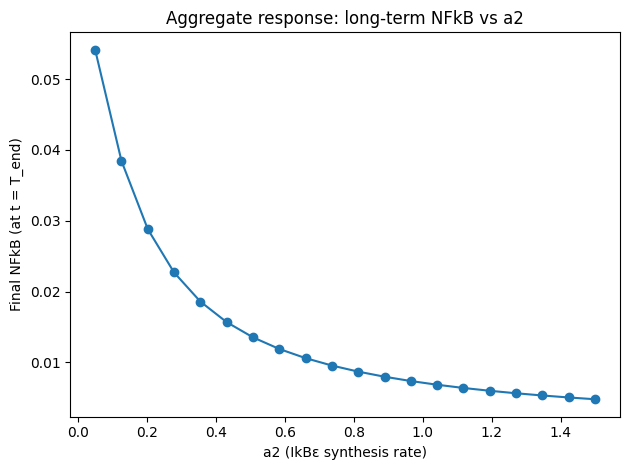

In [85]:
# NFkB vs a2 
# a2 slow feedback strength

a2_values = np.linspace(0.05, 1.5, 20)  # tweak if needed
final_N = []

for a2 in a2_values:
    p = params.copy()
    p["a2"] = a2               # change slow synthesis rate
    t, sol = run_simulation(p)
    N = sol[:, 0]
    final_N.append(N[-1])      # NFkB at final time point

final_N = np.array(final_N)

plt.figure()
plt.plot(a2_values, final_N, marker="o")
plt.xlabel("a2 (IkBε synthesis rate)")
plt.ylabel("Final NFkB (at t = T_end)")
plt.title("Aggregate response: long-term NFkB vs a2")
plt.tight_layout()
plt.show()
